In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from scipy.stats import zscore

In [2]:
folder = r"C:\Users\USER\ML\Lab-2"

In [3]:
df = pd.read_csv(folder + r"\data.csv")

print("First 5 rows of the dataset:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

First 5 rows of the dataset:
   sl_no gender  hsc_p     hsc_s  degree_p   degree_t  etest_p specialisation  \
0      1      M  91.00  Commerce     58.00   Sci&Tech     55.0         Mkt&HR   
1      2      M  78.33   Science     77.48   Sci&Tech     86.5        Mkt&Fin   
2      3      M    NaN      Arts     64.00  Comm&Mgmt     75.0        Mkt&Fin   
3      4      M  52.00   Science       NaN   Sci&Tech     66.0         Mkt&HR   
4      5      M  73.60  Commerce     73.30  Comm&Mgmt     96.8        Mkt&Fin   

   mba_p    salary  
0  58.80  270000.0  
1  66.28  200000.0  
2  57.80  250000.0  
3  59.43       NaN  
4  55.50  425000.0  

Shape of dataset:
(215, 10)


In [4]:
print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nDescriptive statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())


Column names:
Index(['sl_no', 'gender', 'hsc_p', 'hsc_s', 'degree_p', 'degree_t', 'etest_p',
       'specialisation', 'mba_p', 'salary'],
      dtype='str')

Data types:
sl_no               int64
gender                str
hsc_p             float64
hsc_s                 str
degree_p          float64
degree_t              str
etest_p           float64
specialisation        str
mba_p             float64
salary            float64
dtype: object

Descriptive statistics:
            sl_no       hsc_p    degree_p     etest_p       mba_p  \
count  215.000000  210.000000  213.000000  211.000000  214.000000   
mean   108.000000   66.503000   66.420610   72.093649   62.254813   
std     62.209324   10.904205    7.322786   13.340195    5.836962   
min      1.000000   37.000000   50.000000   50.000000   51.210000   
25%     54.500000   61.000000   61.000000   60.000000   57.922500   
50%    108.000000   65.000000   66.000000   70.000000   61.950000   
75%    161.500000   73.000000   72.000000   84.

In [5]:
df = df.dropna(subset=["salary"])

# Replace missing values with mean
df["hsc_p"] = df["hsc_p"].fillna(df["hsc_p"].mean())

df["degree_p"] = df["degree_p"].fillna(df["degree_p"].mean())

df["etest_p"] = df["etest_p"].fillna(df["etest_p"].mean())
df["salary"] = df["salary"].fillna(df["salary"].mean())

print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
sl_no             0
gender            0
hsc_p             0
hsc_s             0
degree_p          0
degree_t          0
etest_p           0
specialisation    0
mba_p             0
salary            0
dtype: int64


In [6]:
numerical_columns = [
    "hsc_p",
    "degree_p",
    "etest_p",
    "salary"
]

In [7]:

standard_scaler = StandardScaler()

standard_data = standard_scaler.fit_transform(
    df[numerical_columns]
)

df_standard = pd.DataFrame(
    standard_data,
    columns=numerical_columns
)

print("\nData after StandardScaler:")
print(df_standard.head())


Data after StandardScaler:
          hsc_p  degree_p   etest_p    salary
0  2.265997e+00 -1.652293 -1.328518 -0.200292
1  8.987875e-01  1.346845  0.978332 -0.951839
2  1.533482e-15 -0.728534  0.136149 -0.415019
3  3.883770e-01  0.703293  1.732635  1.463849
4 -6.475513e-01 -0.420614 -0.449718 -0.393547


In [8]:
minmax_scaler = MinMaxScaler()

minmax_data = minmax_scaler.fit_transform(
    df[numerical_columns]
)

df_minmax = pd.DataFrame(
    minmax_data,
    columns=numerical_columns
)

print("\nData after MinMaxScaler:")
print(df_minmax.head())


Data after MinMaxScaler:
      hsc_p  degree_p   etest_p    salary
0  0.857051  0.057143  0.104167  0.094595
1  0.586729  0.613714  0.760417  0.000000
2  0.409023  0.228571  0.520833  0.067568
3  0.485812  0.494286  0.975000  0.304054
4  0.280990  0.285714  0.354167  0.070270


In [9]:
X = df.drop("salary", axis=1)

Y = df["salary"]

print("\nInput Features X:")
print(X.head())

print("\nTarget Variable Y:")
print(Y.head())



Input Features X:
   sl_no gender     hsc_p     hsc_s  degree_p   degree_t  etest_p  \
0      1      M  91.00000  Commerce     58.00   Sci&Tech     55.0   
1      2      M  78.33000   Science     77.48   Sci&Tech     86.5   
2      3      M  70.00089      Arts     64.00  Comm&Mgmt     75.0   
4      5      M  73.60000  Commerce     73.30  Comm&Mgmt     96.8   
7      8      M  64.00000   Science     66.00   Sci&Tech     67.0   

  specialisation  mba_p  
0         Mkt&HR  58.80  
1        Mkt&Fin  66.28  
2        Mkt&Fin  57.80  
4        Mkt&Fin  55.50  
7        Mkt&Fin  62.14  

Target Variable Y:
0    270000.0
1    200000.0
2    250000.0
4    425000.0
7    252000.0
Name: salary, dtype: float64


In [10]:
df.to_csv(
    folder + r"\Pre.csv",
    index=False
)

print("\nPre.csv saved successfully!")


Pre.csv saved successfully!


In [11]:
salary_zscore = np.abs(
    zscore(df["salary"])
)

outliers = df[salary_zscore > 3]

print("\nSalary outliers:")
print(outliers[["salary"]])

print("\nNumber of salary outliers:")
print(len(outliers))


Salary outliers:
       salary
119  940000.0
150  690000.0
177  650000.0

Number of salary outliers:
3


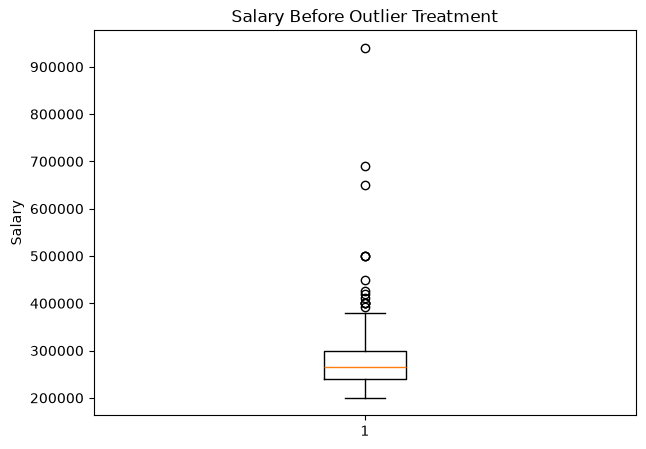

In [12]:
plt.figure(figsize=(7, 5))

plt.boxplot(df["salary"])

plt.title("Salary Before Outlier Treatment")
plt.ylabel("Salary")

plt.savefig(
    folder + r"\salary_before_outlier.png"
)

plt.show()

In [13]:

lower_limit = df["salary"].quantile(0.05)

upper_limit = df["salary"].quantile(0.95)

print("\n5th Percentile:", lower_limit)

print("95th Percentile:", upper_limit)


df["salary"] = df["salary"].clip(
    lower=lower_limit,
    upper=upper_limit
)

print("\nSalary after capping and flooring:")
print(df["salary"].describe())


5th Percentile: 206100.0
95th Percentile: 423250.0

Salary after capping and flooring:
count       148.000000
mean     280356.756757
std       59315.101336
min      206100.000000
25%      240000.000000
50%      265000.000000
75%      300000.000000
max      423250.000000
Name: salary, dtype: float64


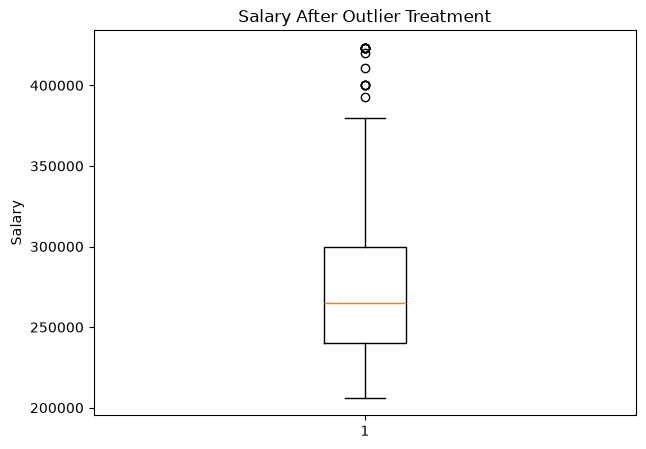

In [14]:
plt.figure(figsize=(7, 5))

plt.boxplot(df["salary"])

plt.title("Salary After Outlier Treatment")
plt.ylabel("Salary")

plt.savefig(
    folder + r"\salary_after_outlier.png"
)

plt.show()

In [15]:
label_encoder = LabelEncoder()

df["gender_encoded"] = label_encoder.fit_transform(
    df["gender"]
)

print("\nGender and Label Encoding:")
print(
    df[["gender", "gender_encoded"]].head()
)

print("\nGender category mapping:")

gender_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(
            label_encoder.classes_
        )
    )
)

print(gender_mapping)


Gender and Label Encoding:
  gender  gender_encoded
0      M               1
1      M               1
2      M               1
4      M               1
7      M               1

Gender category mapping:
{'F': np.int64(0), 'M': np.int64(1)}


In [18]:
df = pd.get_dummies(
    df,
    columns=[
        "gender",
        "hsc_s",
        "degree_t",
        "specialisation"
    ],
    drop_first=True
)


# Convert True/False into 1/0

boolean_columns = df.select_dtypes(
    include="bool"
).columns

df[boolean_columns] = df[
    boolean_columns
].astype(int)

KeyError: "None of [Index(['gender', 'hsc_s', 'degree_t', 'specialisation'], dtype='str')] are in the [columns]"

In [19]:
print("\nFinal Dataset:")
print(df.head())

print("\nFinal Dataset Shape:")
print(df.shape)

print("\nFinal Dataset Data Types:")
print(df.dtypes)

print("\nMissing values in Final Dataset:")
print(df.isnull().sum())


Final Dataset:
   sl_no     hsc_p  degree_p  etest_p  mba_p    salary  gender_encoded  \
0      1  91.00000     58.00     55.0  58.80  270000.0               1   
1      2  78.33000     77.48     86.5  66.28  206100.0               1   
2      3  70.00089     64.00     75.0  57.80  250000.0               1   
4      5  73.60000     73.30     96.8  55.50  423250.0               1   
7      8  64.00000     66.00     67.0  62.14  252000.0               1   

   gender_M  hsc_s_Commerce  hsc_s_Science  degree_t_Others  \
0         1               1              0                0   
1         1               0              1                0   
2         1               0              0                0   
4         1               1              0                0   
7         1               0              1                0   

   degree_t_Sci&Tech  specialisation_Mkt&HR  
0                  1                      1  
1                  1                      0  
2                  0  

In [20]:

df.to_csv(
    folder + r"\Final.csv",
    index=False
)

print("\nFinal.csv saved successfully!")

print("\n======================================")
print("PLACEMENT EXPERIMENT COMPLETED")
print("======================================")


Final.csv saved successfully!

PLACEMENT EXPERIMENT COMPLETED


In [21]:

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from scipy.stats import zscore

In [22]:
folder = r"C:\Users\USER\ML\Lab-2"

In [23]:
df = pd.read_csv(
    folder + r"\automobile.csv"
)

print("First 10 rows:")
print(df.head(10))

print("\nShape of dataset:")
print(df.shape)

First 10 rows:
                        name   mpg  cylinders  displacement  horsepower  \
0  chevrolet chevelle malibu  18.0        8.0         307.0       130.0   
1          buick skylark 320  15.0        8.0         350.0       165.0   
2         plymouth satellite  18.0        8.0         318.0       150.0   
3              amc rebel sst  16.0        8.0         304.0       150.0   
4                ford torino  17.0        NaN         302.0       140.0   
5           ford galaxie 500  15.0        8.0         429.0       198.0   
6           chevrolet impala  14.0        8.0         454.0       220.0   
7          plymouth fury iii  14.0        8.0         440.0       215.0   
8           pontiac catalina  14.0        8.0         455.0         NaN   
9         amc ambassador dpl  15.0        8.0         390.0       190.0   

   weight  acceleration  model_year origin  
0  3504.0          12.0          70    usa  
1  3693.0          11.5          70    usa  
2  3436.0          11.0 

In [24]:
print("\nColumn names:")
print(df.columns)
print("\nData types:")
print(df.dtypes)
print("\nDescriptive statistics:")
print(df.describe())
print("\nNumerical columns:")
print(
    df.select_dtypes(
        include=np.number
    ).columns
)
print("\nCategorical columns:")
print(
    df.select_dtypes(
        include="object"
    ).columns
)
print("\nUnique values in categorical columns:")

for column in df.select_dtypes(
    include="object"
).columns:
    print("\n", column)
    print(
        df[column].unique()
    )


Column names:
Index(['name', 'mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin'],
      dtype='str')

Data types:
name                str
mpg             float64
cylinders       float64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin              str
dtype: object

Descriptive statistics:
              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  395.000000    395.000000  386.000000   396.000000   
mean    23.514573    5.445570    193.340506  104.316062  2965.025253   
std      7.815984    1.696203    104.425993   38.086281   845.254458   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    102.500000   75.250000  2222.250000   
50%     23.000000    4.000000    146.000000   92.500000  2797.500000   
75%     29.000000    8.000000    262.000000  125.000000  3581.750000   

C:\Users\USER\AppData\Local\Temp\ipykernel_14360\3794884825.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(
C:\Users\USER\AppData\Local\Temp\ipykernel_14360\3794884825.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migra

In [25]:
print("\nMissing values:")
print(df.isnull().sum())


print("\nMissing value percentage:")

print(
    (df.isnull().sum() / len(df)) * 100
)


Missing values:
name             0
mpg              0
cylinders        3
displacement     3
horsepower      12
weight           2
acceleration     3
model_year       0
origin           0
dtype: int64

Missing value percentage:
name            0.000000
mpg             0.000000
cylinders       0.753769
displacement    0.753769
horsepower      3.015075
weight          0.502513
acceleration    0.753769
model_year      0.000000
origin          0.000000
dtype: float64


In [26]:
df["horsepower"] = df[
    "horsepower"
].replace("?", np.nan)


# Convert horsepower to numeric

df["horsepower"] = pd.to_numeric(
    df["horsepower"],
    errors="coerce"
)

In [27]:

df["horsepower"] = df[
    "horsepower"
].fillna(
    df["horsepower"].mean()
)

In [28]:

# Numerical columns

numerical_columns = df.select_dtypes(
    include=np.number
).columns

for column in numerical_columns:

    df[column] = df[column].fillna(
        df[column].mean()
    )


# Categorical columns

categorical_columns = df.select_dtypes(
    include="object"
).columns

for column in categorical_columns:

    df[column] = df[column].fillna(
        df[column].mode()[0]
    )


print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
name            0
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_14360\206217637.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [29]:
print("\nNumber of duplicate records:")
print(df.duplicated().sum())


df = df.drop_duplicates()


print("\nDuplicates after removal:")
print(df.duplicated().sum())


Number of duplicate records:
0

Duplicates after removal:
0


In [30]:

origin_map = {
    1: "usa",
    2: "europe",
    3: "japan"
}

df["origin"] = df[
    "origin"
].map(origin_map)


print("\nUnique origin values:")
print(df["origin"].unique())


Unique origin values:
<StringArray>
[nan]
Length: 1, dtype: str


In [31]:
df["weight_kg"] = (
    df["weight"] * 0.453592
)

print("\nWeight conversion:")
print(
    df[
        ["weight", "weight_kg"]
    ].head()
)


Weight conversion:
   weight    weight_kg
0  3504.0  1589.386368
1  3693.0  1675.115256
2  3436.0  1558.542112
3  3433.0  1557.181336
4  3449.0  1564.438808


In [32]:
def create_mpg_category(mpg):

    if mpg < 20:
        return "Low"

    elif mpg < 30:
        return "Medium"

    else:
        return "High"


df["mpg_category"] = df[
    "mpg"
].apply(create_mpg_category)


print("\nMPG categories:")
print(
    df[
        ["mpg", "mpg_category"]
    ].head(10)
)


MPG categories:
    mpg mpg_category
0  18.0          Low
1  15.0          Low
2  18.0          Low
3  16.0          Low
4  17.0          Low
5  15.0          Low
6  14.0          Low
7  14.0          Low
8  14.0          Low
9  15.0          Low


In [33]:
df["vehicle_age"] = (
    2026 - df["model_year"]
)


print("\nVehicle age:")
print(
    df[
        ["model_year", "vehicle_age"]
    ].head()
)


Vehicle age:
   model_year  vehicle_age
0          70         1956
1          70         1956
2          70         1956
3          70         1956
4          70         1956


In [34]:
df = df.rename(
    columns={
        "mpg": "miles_per_gallon",
        "horsepower": "hp",
        "weight": "weight_lbs",
        "model_year": "year"
    }
)


print("\nRenamed columns:")
print(df.columns)


Renamed columns:
Index(['name', 'miles_per_gallon', 'cylinders', 'displacement', 'hp',
       'weight_lbs', 'acceleration', 'year', 'origin', 'weight_kg',
       'mpg_category', 'vehicle_age'],
      dtype='str')


In [35]:
print("\nVehicles with MPG > 30:")
print(
    df[
        df["miles_per_gallon"] > 30
    ]
)


print("\nVehicles with horsepower > 150:")
print(
    df[
        df["hp"] > 150
    ]
)


print("\nVehicles with cylinders >= 6:")
print(
    df[
        df["cylinders"] >= 6
    ]
)


print("\nVehicles manufactured after 1980:")
print(
    df[
        df["year"] > 1980
    ]
)


print("\nVehicles originating from USA:")
print(
    df[
        df["origin"] == "usa"
    ]
)


Vehicles with MPG > 30:
                    name  miles_per_gallon  cylinders  displacement  \
53   toyota corolla 1200              31.0        4.0          71.0   
54           datsun 1200              35.0        4.0          72.0   
129          datsun b210              31.0        4.0          79.0   
131  toyota corolla 1200              32.0        4.0          71.0   
144        toyota corona              31.0        4.0          76.0   
..                   ...               ...        ...           ...   
390     toyota celica gt              32.0        4.0         144.0   
391    dodge charger 2.2              36.0        4.0         135.0   
394            vw pickup              44.0        4.0          97.0   
395        dodge rampage              32.0        4.0         135.0   
397           chevy s-10              31.0        4.0         119.0   

             hp  weight_lbs  acceleration  year origin    weight_kg  \
53    65.000000      1773.0     19.000000    71    

In [36]:
label_encoder = LabelEncoder()

df["origin_encoded"] = (
    label_encoder.fit_transform(
        df["origin"]
    )
)


print("\nOriginal and encoded origin:")
print(
    df[
        ["origin", "origin_encoded"]
    ].head(10)
)


print("\nCategory-to-label mapping:")

mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(
            label_encoder.classes_
        )
    )
)

print(mapping)


Original and encoded origin:
  origin  origin_encoded
0    NaN               0
1    NaN               0
2    NaN               0
3    NaN               0
4    NaN               0
5    NaN               0
6    NaN               0
7    NaN               0
8    NaN               0
9    NaN               0

Category-to-label mapping:
{nan: np.int64(0)}


In [37]:
df_onehot = pd.get_dummies(
    df,
    columns=["origin"],
    prefix="origin"
)


print("\nOne-Hot Encoded Dataset:")
print(
    df_onehot.head()
)



One-Hot Encoded Dataset:
                        name  miles_per_gallon  cylinders  displacement  \
0  chevrolet chevelle malibu              18.0    8.00000         307.0   
1          buick skylark 320              15.0    8.00000         350.0   
2         plymouth satellite              18.0    8.00000         318.0   
3              amc rebel sst              16.0    8.00000         304.0   
4                ford torino              17.0    5.44557         302.0   

      hp  weight_lbs  acceleration  year    weight_kg mpg_category  \
0  130.0      3504.0          12.0    70  1589.386368          Low   
1  165.0      3693.0          11.5    70  1675.115256          Low   
2  150.0      3436.0          11.0    70  1558.542112          Low   
3  150.0      3433.0          12.0    70  1557.181336          Low   
4  140.0      3449.0          10.5    70  1564.438808          Low   

   vehicle_age  origin_encoded  
0         1956               0  
1         1956               0  
2  

In [38]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns


z_scores = np.abs(
    zscore(
        df[numerical_columns]
    )
)


outlier_mask = z_scores > 3


print("\nNumber of outliers in each column:")

for i, column in enumerate(
    numerical_columns
):

    count = outlier_mask[:, i].sum()

    print(
        column,
        ":",
        count
    )


# Display rows containing outliers

outlier_rows = df[
    outlier_mask.any(axis=1)
]


print("\nRows containing outliers:")
print(outlier_rows)


Number of outliers in each column:
miles_per_gallon : 0
cylinders : 0
displacement : 0
hp : 4
weight_lbs : 0
acceleration : 2
year : 0
weight_kg : 0
vehicle_age : 0
origin_encoded : 0

Rows containing outliers:
                         name  miles_per_gallon  cylinders  displacement  \
6            chevrolet impala              14.0        8.0         454.0   
13    buick estate wagon (sw)              14.0        8.0         455.0   
95   buick electra 225 custom              12.0        8.0         455.0   
116        pontiac grand prix              16.0        8.0         400.0   
299               peugeot 504              27.2        4.0         141.0   
394                 vw pickup              44.0        4.0          97.0   

        hp   weight_lbs  acceleration  year origin    weight_kg mpg_category  \
6    220.0  2965.025253           9.0    70    NaN  1344.911734          Low   
13   225.0  3086.000000          10.0    70    NaN  1399.784912          Low   
95   225.0  495

In [39]:
scaler = StandardScaler()

standardized_data = scaler.fit_transform(
    df[numerical_columns]
)


df_standard = pd.DataFrame(
    standardized_data,
    columns=numerical_columns
)


print("\nStandardized values:")
print(
    df_standard.head()
)


print("\nMean after Standardization:")
print(
    df_standard.mean()
)


print("\nStandard deviation after Standardization:")
print(
    df_standard.std()
)


Standardized values:
   miles_per_gallon  cylinders  displacement        hp  weight_lbs  \
0         -0.706439   1.513595      1.093933  0.685653    0.640065   
1         -1.090751   1.513595      1.507792  1.620005    0.864514   
2         -0.706439   1.513595      1.199804  1.219568    0.559311   
3         -0.962647   1.513595      1.065059  1.219568    0.555748   
4         -0.834543   0.000000      1.045809  0.952611    0.574749   

   acceleration      year  weight_kg  vehicle_age  origin_encoded  
0     -1.301810 -1.627426   0.640065     1.627426             0.0  
1     -1.484531 -1.627426   0.864514     1.627426             0.0  
2     -1.667253 -1.627426   0.559311     1.627426             0.0  
3     -1.301810 -1.627426   0.555748     1.627426             0.0  
4     -1.849974 -1.627426   0.574749     1.627426             0.0  

Mean after Standardization:
miles_per_gallon    7.141133e-17
cylinders           1.785283e-16
displacement       -8.926416e-17
hp                 -2

In [40]:
minmax_scaler = MinMaxScaler()

normalized_data = minmax_scaler.fit_transform(
    df[numerical_columns]
)


df_minmax = pd.DataFrame(
    normalized_data,
    columns=numerical_columns
)


print("\nNormalized values:")
print(
    df_minmax.head()
)


Normalized values:
   miles_per_gallon  cylinders  displacement        hp  weight_lbs  \
0          0.239362   1.000000      0.617571  0.456522    0.536150   
1          0.159574   1.000000      0.728682  0.646739    0.589736   
2          0.239362   1.000000      0.645995  0.565217    0.516870   
3          0.186170   1.000000      0.609819  0.565217    0.516019   
4          0.212766   0.489114      0.604651  0.510870    0.520556   

   acceleration  year  weight_kg  vehicle_age  origin_encoded  
0      0.238095   0.0   0.536150          1.0             0.0  
1      0.208333   0.0   0.589736          1.0             0.0  
2      0.178571   0.0   0.516870          1.0             0.0  
3      0.238095   0.0   0.516019          1.0             0.0  
4      0.148810   0.0   0.520556          1.0             0.0  


In [41]:
Y = df[
    "miles_per_gallon"
]


# X = input features

X = df.drop(
    "miles_per_gallon",
    axis=1
)


# One-hot encode categorical columns in X

categorical_X = X.select_dtypes(
    include="object"
).columns


X = pd.get_dummies(
    X,
    columns=categorical_X,
    drop_first=True
)


# Convert True/False to 1/0

boolean_columns = X.select_dtypes(
    include="bool"
).columns


X[boolean_columns] = X[
    boolean_columns
].astype(int)


print("\nShape of X:")
print(X.shape)


print("\nShape of Y:")
print(Y.shape)


Shape of X:
(398, 315)

Shape of Y:
(398,)


C:\Users\USER\AppData\Local\Temp\ipykernel_14360\232117817.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_X = X.select_dtypes(


In [42]:
XY = X.copy()

XY["miles_per_gallon"] = Y


XY.to_csv(
    folder + r"\automobile_X_Y.csv",
    index=False
)


print(
    "\nautomobile_X_Y.csv saved successfully!"
)


automobile_X_Y.csv saved successfully!


In [43]:

loaded_data = pd.read_csv(
    folder + r"\automobile_X_Y.csv"
)


print("\nFirst 5 rows after loading:")
print(
    loaded_data.head()
)


First 5 rows after loading:
   cylinders  displacement     hp  weight_lbs  acceleration  year  \
0    8.00000         307.0  130.0      3504.0          12.0    70   
1    8.00000         350.0  165.0      3693.0          11.5    70   
2    8.00000         318.0  150.0      3436.0          11.0    70   
3    8.00000         304.0  150.0      3433.0          12.0    70   
4    5.44557         302.0  140.0      3449.0          10.5    70   

     weight_kg  vehicle_age  origin_encoded  name_amc ambassador dpl  ...  \
0  1589.386368         1956               0                        0  ...   
1  1675.115256         1956               0                        0  ...   
2  1558.542112         1956               0                        0  ...   
3  1557.181336         1956               0                        0  ...   
4  1564.438808         1956               0                        0  ...   

   name_volvo 264gl  name_volvo diesel  name_vw dasher (diesel)  \
0                 0       

In [44]:
final_df = X.copy()

final_df[
    "miles_per_gallon"
] = Y


print("\nFinal Dataset:")
print(
    final_df.head()
)


# Check missing values

print("\nMissing values in final dataset:")
print(
    final_df.isnull().sum()
)


# Save final dataset

final_df.to_csv(
    folder + r"\automobile_preprocessed.csv",
    index=False
)


print(
    "\nautomobile_preprocessed.csv saved successfully!"
)


print("\n======================================")
print("AUTOMOBILE EXPERIMENT COMPLETED")
print("======================================")


Final Dataset:
   cylinders  displacement     hp  weight_lbs  acceleration  year  \
0    8.00000         307.0  130.0      3504.0          12.0    70   
1    8.00000         350.0  165.0      3693.0          11.5    70   
2    8.00000         318.0  150.0      3436.0          11.0    70   
3    8.00000         304.0  150.0      3433.0          12.0    70   
4    5.44557         302.0  140.0      3449.0          10.5    70   

     weight_kg  vehicle_age  origin_encoded  name_amc ambassador dpl  ...  \
0  1589.386368         1956               0                        0  ...   
1  1675.115256         1956               0                        0  ...   
2  1558.542112         1956               0                        0  ...   
3  1557.181336         1956               0                        0  ...   
4  1564.438808         1956               0                        0  ...   

   name_volvo 264gl  name_volvo diesel  name_vw dasher (diesel)  \
0                 0                  0 